<a href="https://colab.research.google.com/github/mahwishk3/blockchain-banking-pakistan/blob/main/frauddetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
import pandas as pd

# Try with error handling
df_fraud = pd.read_csv("creditcard.csv", on_bad_lines='skip')
df_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [99]:
df_fraud.info()
df_fraud.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [100]:
df_fraud = df_fraud.dropna()

In [101]:
df_fraud.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [102]:
df_fraud['Class'].value_counts()

,count
Class,
0,284315
1,492


In [103]:
df_fraud.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [104]:
df_fraud.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [105]:
df_fraud.shape

(284807, 31)

In [106]:
df_fraud.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [107]:
df_fraud.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [108]:
df_fraud.duplicated().sum()

np.int64(1081)

In [109]:
df_fraud = df_fraud.drop_duplicates()

In [110]:
df_fraud.duplicated().sum()

np.int64(0)

In [111]:
df_fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


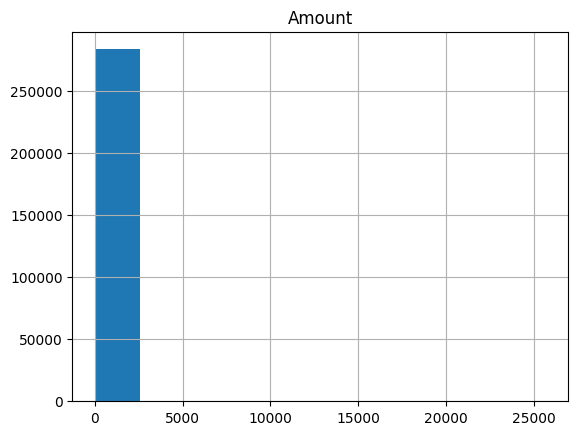

In [112]:
df_fraud[['Amount']].hist()
plt.savefig("amount_histogram.png")
plt.show()

In [113]:
from google.colab import files
files.download('amount_histogram.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [114]:
plt.savefig("amount_histogram.png")

<Figure size 640x480 with 0 Axes>

In [115]:
from google.colab import files
files.download('amount_histogram.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

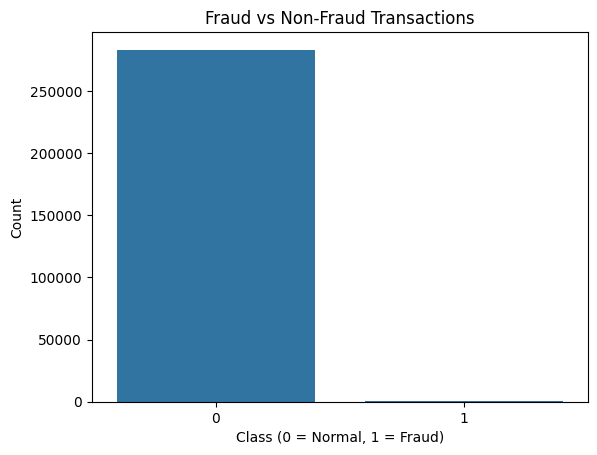

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df_fraud)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.savefig("class_distribution_countplot.png")
plt.show()

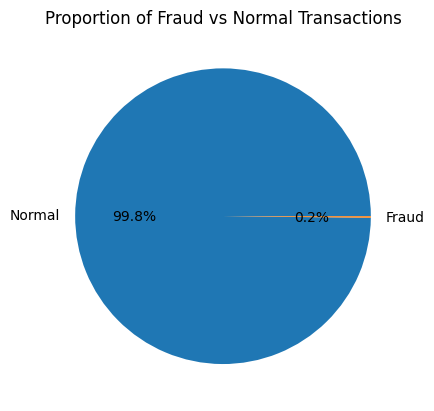

In [117]:
df_fraud['Class'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Normal', 'Fraud']
)

plt.title("Proportion of Fraud vs Normal Transactions")
plt.ylabel("")
plt.savefig("fraud_proportion_pie_chart.png")
plt.show()

In [118]:
from google.colab import files
files.download('fraud_proportion_pie_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

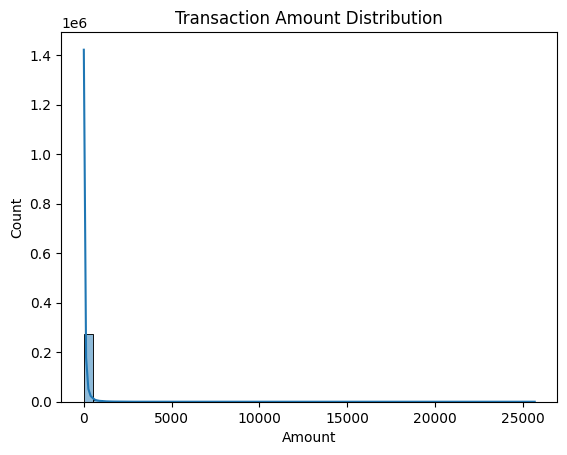

In [119]:
sns.histplot(df_fraud['Amount'], bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.savefig("transaction_amount_distribution.png")
plt.show()

In [120]:
from google.colab import files
files.download('transaction_amount_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

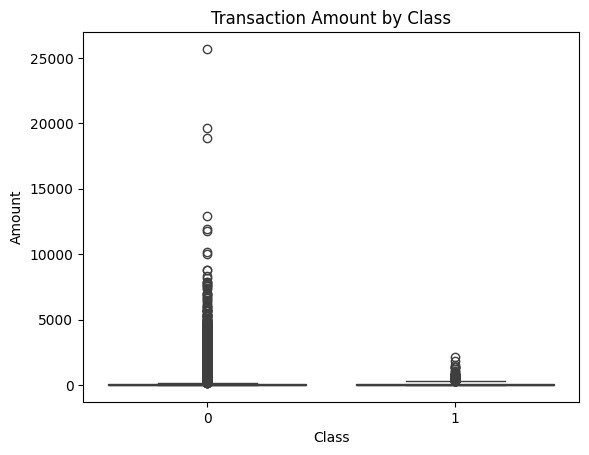

In [121]:
sns.boxplot(x='Class', y='Amount', data=df_fraud)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

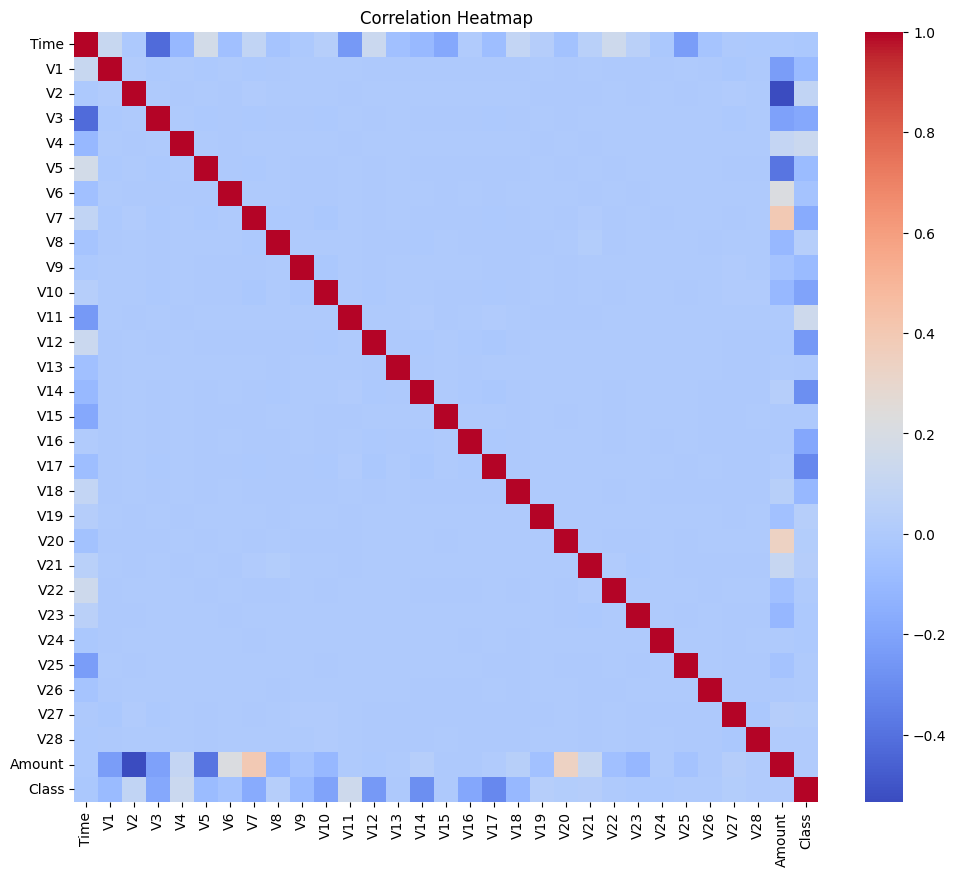

In [122]:
import pandas as pd

# List of columns identified as 'object' type that should be numeric
object_cols = ['V1', 'V2', 'V4', 'V7', 'V8', 'V10', 'V11', 'V13', 'V15', 'V17', 'V21', 'V22', 'V23', 'V24']

# Convert these columns to numeric, coercing errors to NaN
for col in object_cols:
    df_fraud[col] = pd.to_numeric(df_fraud[col], errors='coerce')

# Drop any new NaNs that might have been introduced during conversion
df_fraud = df_fraud.dropna()

corr = df_fraud.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png") # Added this line to save the plot
plt.show()

In [123]:
from google.colab import files
files.download('correlation_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

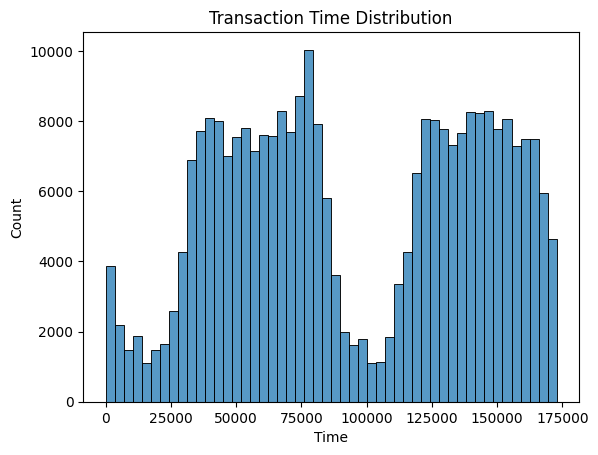

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_fraud['Time'], bins=50)

plt.title("Transaction Time Distribution")
plt.savefig("transaction_time_distribution.png")
plt.show()

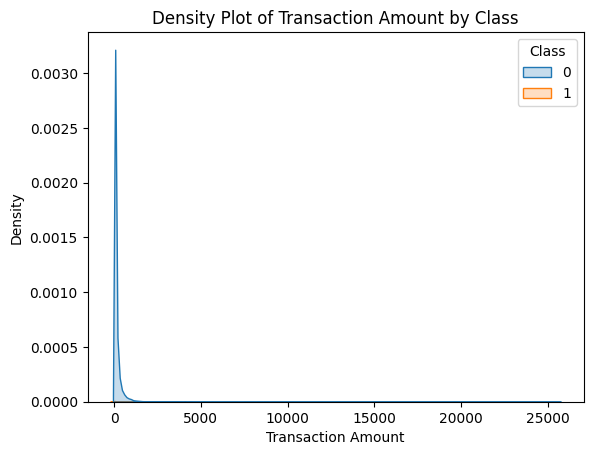

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=df_fraud, x='Amount', hue='Class', fill=True)

plt.title("Density Plot of Transaction Amount by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

In [126]:
plt.savefig("density_plot_amount_by_class.png")

<Figure size 640x480 with 0 Axes>

In [127]:
from google.colab import files
files.download('density_plot_amount_by_class.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

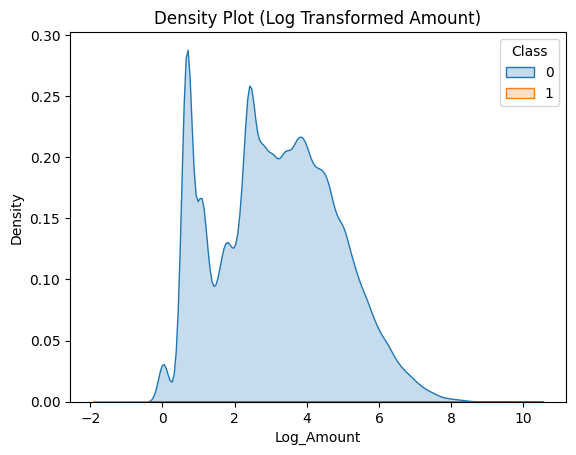

In [128]:
import numpy as np

df_fraud['Log_Amount'] = np.log1p(df_fraud['Amount'])

sns.kdeplot(data=df_fraud, x='Log_Amount', hue='Class', fill=True)

plt.title("Density Plot (Log Transformed Amount)")
plt.show()

In [129]:
plt.savefig("density_plot_log_amount.png")

<Figure size 640x480 with 0 Axes>

In [130]:
from google.colab import files
files.download('density_plot_log_amount.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

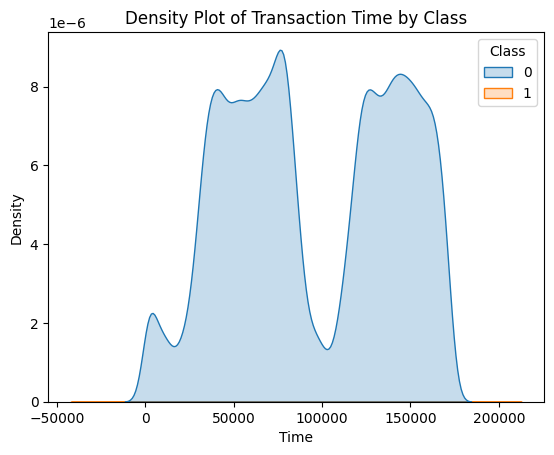

In [131]:
sns.kdeplot(data=df_fraud, x='Time', hue='Class', fill=True)

plt.title("Density Plot of Transaction Time by Class")
plt.show()

In [132]:
plt.savefig("time_density_plot_by_class.png")

<Figure size 640x480 with 0 Axes>

In [133]:
from google.colab import files
files.download('time_density_plot_by_class.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

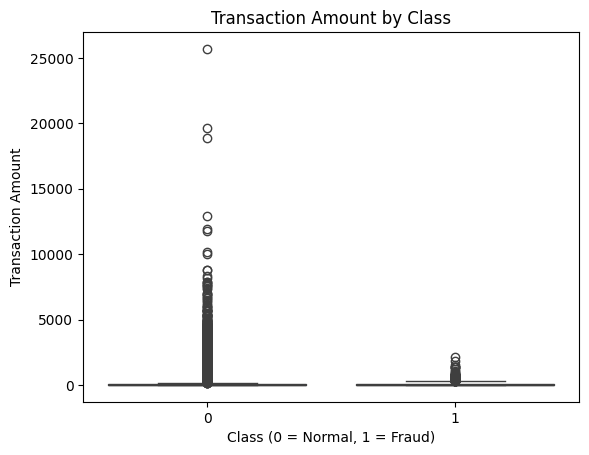

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Class', y='Amount', data=df_fraud)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.savefig("transaction_amount_by_class.png") # Save this plot
plt.show()

In [135]:
from google.colab import files
files.download('transaction_amount_by_class.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

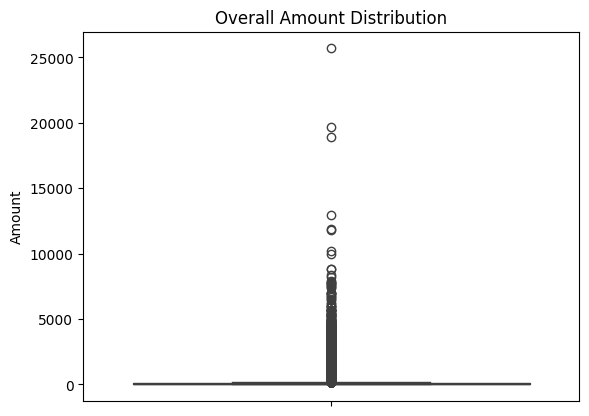

In [136]:
sns.boxplot(y='Amount', data=df_fraud)
plt.title("Overall Amount Distribution")
plt.savefig("overall_amount_distribution.png")
plt.show()

In [137]:
from google.colab import files
files.download('overall_amount_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

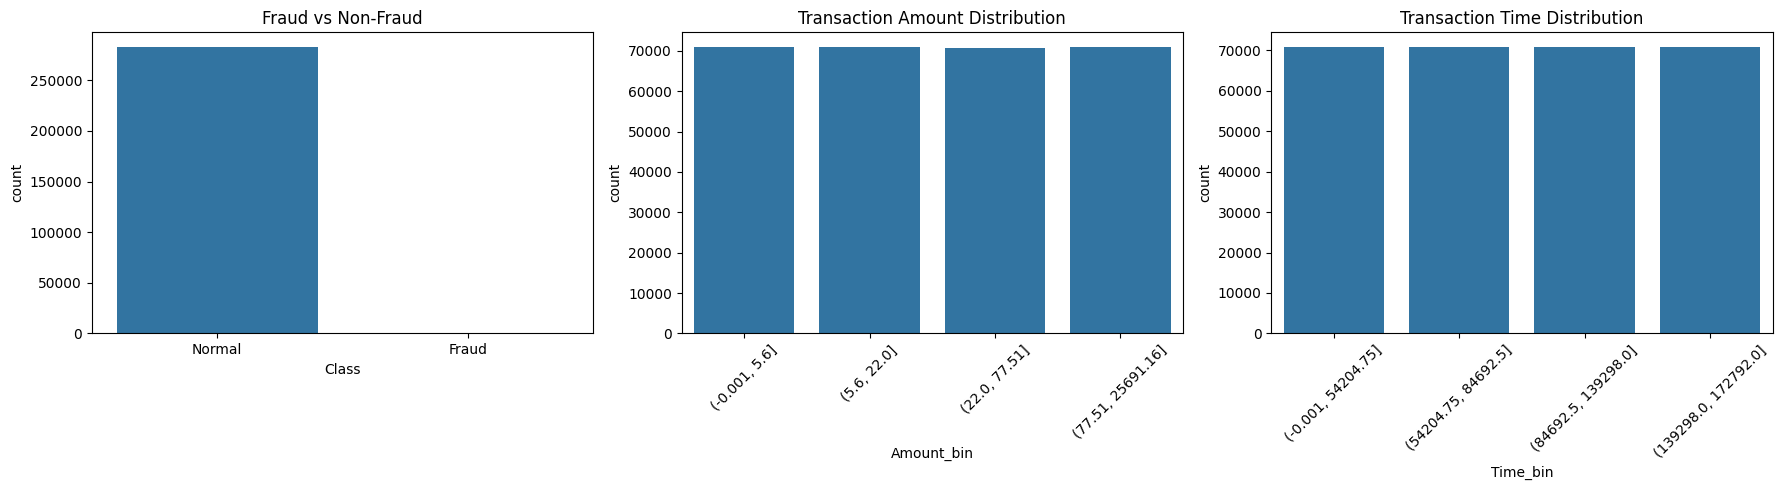

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution (main)
sns.countplot(data=df_fraud, x='Class', ax=axes[0])
axes[0].set_title('Fraud vs Non-Fraud')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Fraud'])

# 2. Binned Amount (convert to categories)
df_fraud['Amount_bin'] = pd.qcut(df_fraud['Amount'], q=4, duplicates='drop')
sns.countplot(data=df_fraud, x='Amount_bin', ax=axes[1])
axes[1].set_title('Transaction Amount Distribution')
axes[1].tick_params(axis='x', rotation=45)

# 3. Binned Time (convert to categories)
df_fraud['Time_bin'] = pd.qcut(df_fraud['Time'], q=4, duplicates='drop')
sns.countplot(data=df_fraud, x='Time_bin', ax=axes[2])
axes[2].set_title('Transaction Time Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [139]:
# Save the figure containing the subplots
fig.savefig("fraud_subplots.png")

# Download the figure
from google.colab import files
files.download('fraud_subplots.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [140]:
X = df_fraud.drop(['Class', 'Amount_bin', 'Time_bin'], axis=1)
y = df_fraud['Class']

In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [142]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [145]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)  # increased iterations
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [146]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [147]:
y_pred = model.predict(X_test)

In [148]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9991541254009093
Precision: 0.8888888888888888
Recall: 0.5333333333333333
F1 Score: 0.6666666666666666


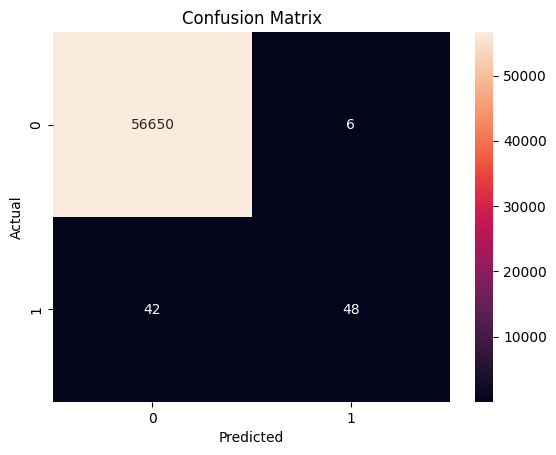

In [149]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [150]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [151]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [152]:
y_pred_rf = rf_model.predict(X_test)

In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.9995241955380115
Precision: 0.9701492537313433
Recall: 0.7222222222222222
F1 Score: 0.8280254777070064


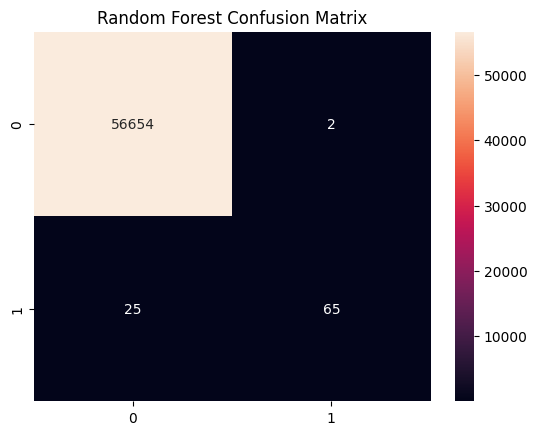

In [154]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.savefig("rf_confusion_matrix.png") # Save the figure
plt.show()

In [155]:
from google.colab import files
files.download('rf_confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

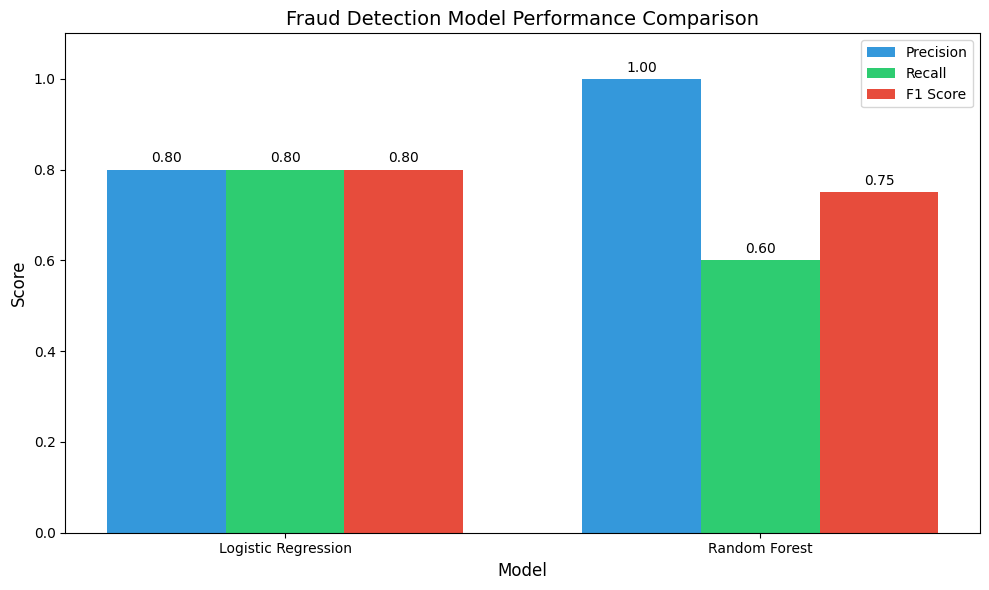

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [156]:
import matplotlib.pyplot as plt
import numpy as np

# Your actual results
models = ['Logistic Regression', 'Random Forest']
precision = [0.80, 1.00]
recall = [0.80, 0.60]
f1_score = [0.80, 0.75]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498DB')
bars2 = ax.bar(x, recall, width, label='Recall', color='#2ECC71')
bars3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='#E74C3C')

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Fraud Detection Model Performance Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()

from google.colab import files
files.download('model_performance_comparison.png')

In [157]:
from google.colab import files
files.download('model_performance_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>